In [2]:
# Load outputs from the previous notebook.
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("/content")
INTERMEDIATE_FILE = DATA_DIR / "experiment_outputs.pkl"

with open(INTERMEDIATE_FILE, "rb") as file:
    experiment_outputs = pickle.load(file)

globals().update(experiment_outputs)

print("Loaded:", INTERMEDIATE_FILE)

Loaded: /content/experiment_outputs.pkl


## Cross-Experiment Comparison

The feature sets expand from voltage/history in A, to temperature in B, and operating context in C. All three experiments use the same 10,676 observations.


In [3]:
def get_silhouette(summary_df, model_name):
    return float(
        summary_df.loc[
            summary_df["model"] == model_name,
            "silhouette_score"
        ].iloc[0]
    )


cross_experiment_comparison = pd.DataFrame({
    "Experiment": ["A", "B", "C"],
    "Feature count": [
        len(base_feature_columns),
        len(experiment_b_feature_columns),
        len(experiment_c_feature_columns)
    ],
    "Observations": [
        len(model_df),
        len(experiment_b_model_df),
        len(experiment_c_df)
    ],
    "IF anomalies": [
        int(isolation_forest_results["is_anomalous"].sum()),
        int(if_results_b["is_anomalous"].sum()),
        int(if_results_c["is_anomalous"].sum())
    ],
    "OCSVM anomalies": [
        int(ocsvm_results["is_anomalous"].sum()),
        int(ocsvm_results_b["is_anomalous"].sum()),
        int(ocsvm_results_c["is_anomalous"].sum())
    ],
    "AE anomalies": [
        int(autoencoder_results["is_anomalous"].sum()),
        int(autoencoder_results_b["is_anomalous"].sum()),
        int(autoencoder_results_c["is_anomalous"].sum())
    ],
    "Consensus anomalies": [
        int(consensus_results["consensus_anomaly"].sum()),
        int(consensus_results_b["consensus_anomaly"].sum()),
        int(consensus_results_c["consensus_anomaly"].sum())
    ],
    "IF Silhouette": [
        get_silhouette(silhouette_summary, "Isolation Forest"),
        get_silhouette(silhouette_summary_b, "Isolation Forest"),
        get_silhouette(silhouette_summary_c, "Isolation Forest")
    ],
    "OCSVM Silhouette": [
        get_silhouette(silhouette_summary, "One-Class SVM"),
        get_silhouette(silhouette_summary_b, "One-Class SVM"),
        get_silhouette(silhouette_summary_c, "One-Class SVM")
    ],
    "AE Silhouette": [
        get_silhouette(silhouette_summary, "Autoencoder"),
        get_silhouette(silhouette_summary_b, "Autoencoder"),
        get_silhouette(silhouette_summary_c, "Autoencoder")
    ]
})

display(cross_experiment_comparison.round(4))

,Experiment,Feature count,Observations,IF anomalies,OCSVM anomalies,AE anomalies,Consensus anomalies,IF Silhouette,OCSVM Silhouette,AE Silhouette
0,A,5,10676,1710,537,534,300,0.5037,0.5296,0.6110
1,B,8,10676,1613,534,534,275,0.4018,0.4308,0.5007
2,C,12,10676,1634,532,534,297,0.4147,0.4422,0.4925


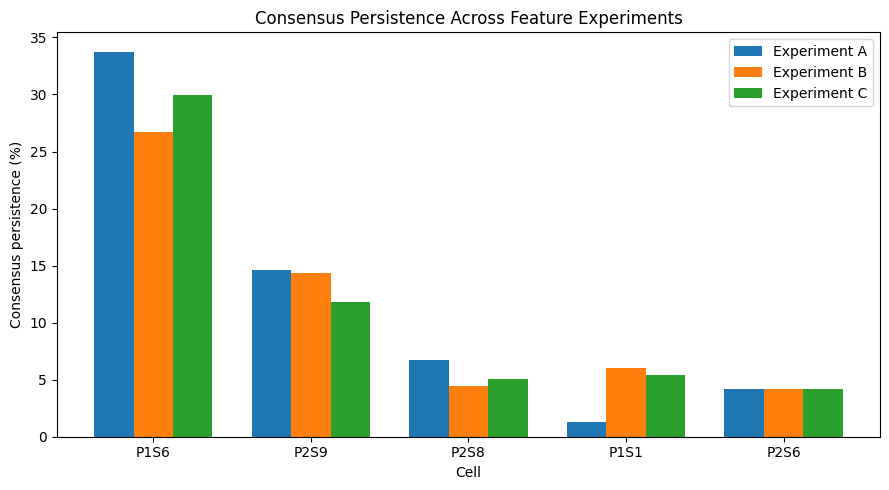

In [4]:
consensus_for_plot = (
    consensus_cell_summary[["cell", "consensus_percentage"]]
    .rename(columns={"consensus_percentage": "Experiment A"})
    .merge(
        consensus_cell_summary_b[["cell", "consensus_percentage"]]
        .rename(columns={"consensus_percentage": "Experiment B"}),
        on="cell"
    )
    .merge(
        consensus_cell_summary_c[["cell", "consensus_percentage"]]
        .rename(columns={"consensus_percentage": "Experiment C"}),
        on="cell"
    )
)

# Select the top cells using their mean consensus persistence across A, B and C.
consensus_for_plot["mean_consensus"] = consensus_for_plot[
    ["Experiment A", "Experiment B", "Experiment C"]
].mean(axis=1)

consensus_for_plot = consensus_for_plot.nlargest(5, "mean_consensus")

x_positions = np.arange(len(consensus_for_plot))
bar_width = 0.25

plt.figure(figsize=(9, 5))

for offset, experiment in zip(
    [-bar_width, 0, bar_width],
    ["Experiment A", "Experiment B", "Experiment C"]
):
    plt.bar(
        x_positions + offset,
        consensus_for_plot[experiment],
        width=bar_width,
        label=experiment
    )

plt.xticks(x_positions, consensus_for_plot["cell"])
plt.xlabel("Cell")
plt.ylabel("Consensus persistence (%)")
plt.title("Consensus Persistence Across Feature Experiments")
plt.legend()
plt.tight_layout()
plt.show()

Silhouette is not accuracy. The plot is a descriptive comparison because A/B/C use different feature spaces.


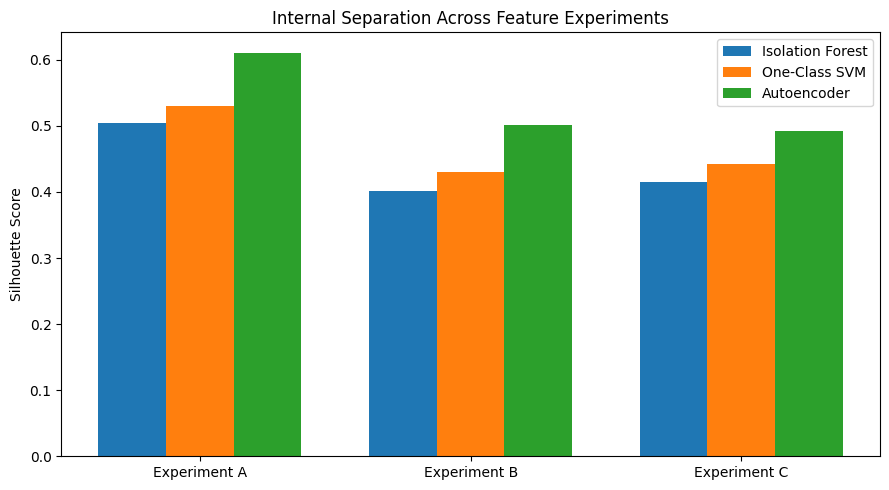

In [5]:
experiments = cross_experiment_comparison["Experiment"].map(
    {
        "A": "Experiment A",
        "B": "Experiment B",
        "C": "Experiment C"
    }
)

x_positions = np.arange(len(experiments))
bar_width = 0.25

plt.figure(figsize=(9, 5))

for offset, column, label in [
    (-bar_width, "IF Silhouette", "Isolation Forest"),
    (0, "OCSVM Silhouette", "One-Class SVM"),
    (bar_width, "AE Silhouette", "Autoencoder")
]:
    plt.bar(
        x_positions + offset,
        cross_experiment_comparison[column],
        width=bar_width,
        label=label
    )

plt.xticks(x_positions, experiments)
plt.ylabel("Silhouette Score")
plt.title("Internal Separation Across Feature Experiments")
plt.legend()
plt.tight_layout()
plt.show()

### Cross-Experiment Interpretation

P1S6 and P2S9 remained persistent anomaly candidates across all three feature sets. P1S6 consensus persistence was 33.76%, 26.75% and 29.94% in A/B/C; P2S9 persistence was 14.65%, 14.33% and 11.78%.


## Sensitivity and Robustness Analysis

Experiment C is tested using lower and higher alternatives around the main Isolation Forest, One-Class SVM and Autoencoder settings. These values test stability and are not claimed to be optimal.


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM


def sensitivity_summary(labels, parameter_value, model_name):
    temp = experiment_c_df[["cycle", "cell"]].copy()
    temp["is_anomalous"] = labels

    cell_summary = (
        temp.groupby("cell")
        .agg(
            anomalous_cycles=("is_anomalous", "sum"),
            total_cycles=("cycle", "count")
        )
        .reset_index()
    )

    cell_summary["anomaly_percentage"] = (
        cell_summary["anomalous_cycles"]
        / cell_summary["total_cycles"]
        * 100
    )

    # Identify the leading persistent cell without pre-selecting a cell name.
    top_cell = cell_summary.sort_values(
        ["anomalous_cycles", "cell"],
        ascending=[False, True]
    ).iloc[0]

    return {
        "Model": model_name,
        "Parameter": parameter_value,
        "Total anomalies": int(np.sum(labels)),
        "Top persistent cell": top_cell["cell"],
        "Top cell cycles": int(top_cell["anomalous_cycles"]),
        "Top cell percent": float(top_cell["anomaly_percentage"])
    }


if_sensitivity_results = []

for contamination_value in ["auto", 0.03, 0.05, 0.08, 0.10]:

    model = IsolationForest(
        n_estimators=200,
        contamination=contamination_value,
        random_state=42
    )

    labels = model.fit_predict(X_scaled_c) == -1

    if_sensitivity_results.append(
        sensitivity_summary(
            labels,
            contamination_value,
            "Isolation Forest"
        )
    )


ocsvm_sensitivity_results = []

for nu_value in [0.02, 0.05, 0.08, 0.10]:

    model = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=nu_value
    )

    labels = model.fit_predict(X_scaled_c) == -1

    ocsvm_sensitivity_results.append(
        sensitivity_summary(
            labels,
            nu_value,
            "One-Class SVM"
        )
    )


ae_sensitivity_results = []

for percentile_value in [90, 95, 97.5, 99]:

    threshold = np.percentile(
        reconstruction_error_c,
        percentile_value
    )

    labels = reconstruction_error_c > threshold

    result = sensitivity_summary(
        labels,
        percentile_value,
        "Autoencoder"
    )

    result["Threshold"] = threshold
    ae_sensitivity_results.append(result)


if_sensitivity_df = pd.DataFrame(if_sensitivity_results)
ocsvm_sensitivity_df = pd.DataFrame(ocsvm_sensitivity_results)
ae_sensitivity_df = pd.DataFrame(ae_sensitivity_results)

print("Isolation Forest sensitivity")
display(if_sensitivity_df.round(2))

print("\nOne-Class SVM sensitivity")
display(ocsvm_sensitivity_df.round(2))

print("\nAutoencoder threshold sensitivity")
display(ae_sensitivity_df.round(4))

Isolation Forest sensitivity


,Model,Parameter,Total anomalies,Top persistent cell,Top cell cycles,Top cell percent
0,Isolation Forest,auto,1634,P1S6,272,86.62
1,Isolation Forest,0.03,321,P1S6,166,52.87
2,Isolation Forest,0.05,534,P1S6,200,63.69
3,Isolation Forest,0.08,854,P1S6,231,73.57
4,Isolation Forest,0.1,1068,P1S6,248,78.98



One-Class SVM sensitivity


,Model,Parameter,Total anomalies,Top persistent cell,Top cell cycles,Top cell percent
0,One-Class SVM,0.02,218,P1S6,39,12.42
1,One-Class SVM,0.05,532,P1S6,104,33.12
2,One-Class SVM,0.08,851,P1S6,162,51.59
3,One-Class SVM,0.10,1068,P1S6,201,64.01



Autoencoder threshold sensitivity


,Model,Parameter,Total anomalies,Top persistent cell,Top cell cycles,Top cell percent,Threshold
0,Autoencoder,90.0,1068,P1S6,238,75.7962,0.7805
1,Autoencoder,95.0,534,P1S6,223,71.0191,1.2245
2,Autoencoder,97.5,267,P1S6,194,61.7834,2.4352
3,Autoencoder,99.0,107,P1S6,89,28.3439,3.9150


### Sensitivity Analysis Interpretation

Anomaly counts changed across the tested settings, but P1S6 remained the top persistent cell for all three methods.

### Supplementary Robustness Check: Matched Anomaly Rate

This supplementary check uses Isolation Forest `contamination=0.05` with the main One-Class SVM and Autoencoder decisions. It examines the effect of more similar anomaly rates without replacing the main Experiment C result.


In [7]:
# Supplementary check: match the Isolation Forest anomaly rate to approximately 5%.
matched_if_c = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

matched_if_labels_c = matched_if_c.fit_predict(X_scaled_c) == -1

matched_rate_consensus_c = experiment_c_df[["cycle", "cell"]].copy()

matched_rate_consensus_c["if_anomalous_5_percent"] = matched_if_labels_c
matched_rate_consensus_c["ocsvm_anomalous"] = ocsvm_results_c["is_anomalous"].to_numpy()
matched_rate_consensus_c["autoencoder_anomalous"] = autoencoder_results_c["is_anomalous"].to_numpy()

matched_rate_consensus_c["consensus_anomaly"] = (
    matched_rate_consensus_c[
        [
            "if_anomalous_5_percent",
            "ocsvm_anomalous",
            "autoencoder_anomalous"
        ]
    ].all(axis=1)
)

matched_rate_persistence_c = (
    matched_rate_consensus_c
    .groupby("cell")
    .agg(
        consensus_anomalous_cycles=("consensus_anomaly", "sum"),
        total_cycles=("cycle", "count")
    )
    .reset_index()
)

matched_rate_persistence_c["consensus_percentage"] = (
    matched_rate_persistence_c["consensus_anomalous_cycles"]
    / matched_rate_persistence_c["total_cycles"]
    * 100
)

matched_rate_comparison_c = (
    consensus_cell_summary_c[
        [
            "cell",
            "consensus_anomalous_cycles",
            "consensus_percentage"
        ]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "main_consensus_cycles",
        "consensus_percentage": "main_consensus_percent"
    })
    .merge(
        matched_rate_persistence_c,
        on="cell",
        how="outer"
    )
    .sort_values(
        ["consensus_anomalous_cycles", "main_consensus_cycles"],
        ascending=False
    )
)

print("Main Experiment C model anomaly rates (%):")
print("Isolation Forest:", round(if_results_c["is_anomalous"].mean() * 100, 2))
print("One-Class SVM:", round(ocsvm_results_c["is_anomalous"].mean() * 100, 2))
print("Autoencoder:", round(autoencoder_results_c["is_anomalous"].mean() * 100, 2))

print("\nMain versus supplementary consensus persistence:")

display(
    matched_rate_comparison_c
    .head(15)
    .round(2)
)

Main Experiment C model anomaly rates (%):
Isolation Forest: 15.31
One-Class SVM: 4.98
Autoencoder: 5.0

Main versus supplementary consensus persistence:


,cell,main_consensus_cycles,main_consensus_percent,consensus_anomalous_cycles,total_cycles,consensus_percentage
7,P1S6,94,29.94,80,314,25.48
22,P2S9,37,11.78,31,314,9.87
21,P2S8,16,5.10,11,314,3.50
19,P2S6,13,4.14,8,314,2.55
0,P1S1,17,5.41,7,314,2.23
30,P3S6,8,2.55,7,314,2.23
33,P3S9,7,2.23,7,314,2.23
28,P3S4,8,2.55,6,314,1.91
24,P3S10,7,2.23,6,314,1.91
26,P3S2,7,2.23,6,314,1.91


## Maintenance-Priority Ranking

The score is the mean consensus persistence across A/B/C. Experiment C persistence is only a tie-break because it contains the complete feature set. The ranking identifies inspection priorities, not failure probabilities.


In [8]:
# Build the final maintenance-priority ranking
# from consensus persistence across Experiments A, B and C.

priority_a = (
    consensus_cell_summary[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "A_consensus_cycles",
        "consensus_percentage": "A_consensus_percent"
    })
)

priority_b = (
    consensus_cell_summary_b[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "B_consensus_cycles",
        "consensus_percentage": "B_consensus_percent"
    })
)

priority_c = (
    consensus_cell_summary_c[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "C_consensus_cycles",
        "consensus_percentage": "C_consensus_percent"
    })
)

maintenance_priority = (
    priority_a
    .merge(priority_b, on="cell", how="outer")
    .merge(priority_c, on="cell", how="outer")
    .fillna(0)
)

maintenance_priority["mean_consensus_percent"] = maintenance_priority[
    [
        "A_consensus_percent",
        "B_consensus_percent",
        "C_consensus_percent"
    ]
].mean(axis=1)

maintenance_priority = (
    maintenance_priority
    .sort_values(
        ["mean_consensus_percent", "C_consensus_percent"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

maintenance_priority["maintenance_priority_rank"] = np.arange(
    1,
    len(maintenance_priority) + 1
)

maintenance_priority = maintenance_priority[
    [
        "maintenance_priority_rank",
        "cell",
        "A_consensus_cycles",
        "A_consensus_percent",
        "B_consensus_cycles",
        "B_consensus_percent",
        "C_consensus_cycles",
        "C_consensus_percent",
        "mean_consensus_percent"
    ]
]

display(
    maintenance_priority
    .head(15)
    .round(2)
)

,maintenance_priority_rank,cell,A_consensus_cycles,A_consensus_percent,B_consensus_cycles,B_consensus_percent,C_consensus_cycles,C_consensus_percent,mean_consensus_percent
0,1,P1S6,106,33.76,84,26.75,94,29.94,30.15
1,2,P2S9,46,14.65,45,14.33,37,11.78,13.59
2,3,P2S8,21,6.69,14,4.46,16,5.10,5.41
3,4,P1S1,4,1.27,19,6.05,17,5.41,4.25
4,5,P2S6,13,4.14,13,4.14,13,4.14,4.14
5,6,P1S7,4,1.27,9,2.87,9,2.87,2.34
6,7,P3S12,9,2.87,7,2.23,6,1.91,2.34
7,8,P1S12,8,2.55,5,1.59,5,1.59,1.91
8,9,P3S6,2,0.64,7,2.23,8,2.55,1.80
9,10,P3S10,4,1.27,4,1.27,7,2.23,1.59


Higher values show more persistent agreement between the three models across A/B/C.


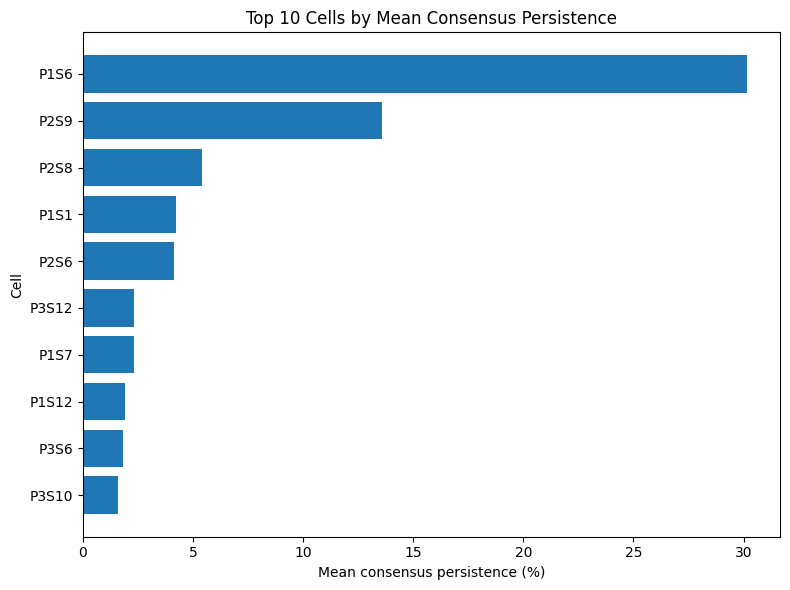

In [9]:
top_10_priority = (
    maintenance_priority.head(10)
    .sort_values("mean_consensus_percent")
)

plt.figure(figsize=(8, 6))
plt.barh(top_10_priority["cell"], top_10_priority["mean_consensus_percent"])
plt.xlabel("Mean consensus persistence (%)")
plt.ylabel("Cell")
plt.title("Top 10 Cells by Mean Consensus Persistence")
plt.tight_layout()
plt.show()


### Feature Profiles of the Highest-Priority Candidates

The table shows the strongest average standardised Experiment C feature differences for the top candidates. These are descriptive associations, not exact model attribution or evidence of degradation.


In [10]:
top_priority_cells = maintenance_priority.head(3)["cell"].tolist()

candidate_feature_profiles = X_scaled_c.copy()
candidate_feature_profiles["cell"] = experiment_c_df["cell"].to_numpy()

candidate_feature_profiles = (
    candidate_feature_profiles[
        candidate_feature_profiles["cell"].isin(top_priority_cells)
    ]
    .groupby("cell")[experiment_c_feature_columns]
    .mean()
)

profile_records = []

for cell in top_priority_cells:
    profile = candidate_feature_profiles.loc[cell]

    # Show the five largest average departures from the overall standardized mean.
    for feature in profile.abs().nlargest(5).index:

        direction = (
            "above overall mean"
            if profile[feature] > 0
            else "below overall mean"
        )

        profile_records.append({
            "cell": cell,
            "feature": feature,
            "mean_standardized_value": profile[feature],
            "direction": direction
        })

candidate_profile_summary = pd.DataFrame(profile_records)

display(candidate_profile_summary.round(3))

,cell,feature,mean_standardized_value,direction
0,P1S6,lowest_voltage_frequency,4.187,above overall mean
1,P1S6,load_response_difference,2.570,above overall mean
2,P1S6,high_load_voltage_deviation,2.029,above overall mean
3,P1S6,voltage_deviation,1.580,above overall mean
4,P1S6,low_soc_voltage_deviation,0.975,above overall mean
5,P2S9,lowest_voltage_frequency,0.616,above overall mean
6,P2S9,temperature_deviation,-0.326,below overall mean
7,P2S9,temperature_mean,0.296,above overall mean
8,P2S9,temperature_max,0.281,above overall mean
9,P2S9,voltage_deviation,0.247,above overall mean


### Maintenance-Priority Interpretation

The ranking begins with P1S6 (30.15%), P2S9 (13.59%), P2S8 (5.41%), P1S1 (4.25%) and P2S6 (4.14%). These percentages describe consensus persistence, not failure probability.


## Methodological Limitations

There are no ground-truth physical fault labels or external validation across other packs, vehicles or chemistries. The analysis uses one battery-pack dataset and focuses on retained WLTP segments rather than separately modelling charging, balancing or other modes.

The full prepared unlabeled dataset is used in-sample. The Autoencoder is trained and scored on the same data, so some unusual patterns may also be learned during training. Results depend on model settings and thresholds. Five partial WLTP segments were removed using a coverage-quality rule, and the operating-context features use relative within-cycle quartiles.
